Analiza wnioskow o kredyt hipoteczny
cel projektu: analiza danych klientów i sprawdzenie, co wpływa na przyznanie kredytu.

1. wczytanie i czyszczenie danych oraz analiza opisowa
usuwamy zbędne ID, wypelniamy braki w kwocie kredytu i sprawdzamy podstawowe statystyki

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('Hipoteczny.csv')

df = df.drop('Loan_ID', axis=1)
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df = df.dropna()

print("Rozmiar danych po czyszczeniu:", df.shape)
display(df.describe())
print("\nStatusy kredytów (Y - Tak, N - Nie):")
print(df['Loan_Status'].value_counts())

Rozmiar danych po czyszczeniu: (511, 12)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,511.000000,511.000000,511.000000,511.000000,511.000000
mean,5308.146771,1561.997886,143.536204,342.434442,0.843444
std,5561.209487,2559.383166,78.324777,64.150735,0.363738
min,150.000000,0.000000,9.000000,36.000000,0.000000
25%,2885.500000,0.000000,100.000000,360.000000,1.000000
50%,3858.000000,1086.000000,128.000000,360.000000,1.000000
75%,5820.000000,2253.500000,165.500000,360.000000,1.000000
max,81000.000000,33837.000000,600.000000,480.000000,1.000000



Statusy kredytów (Y - Tak, N - Nie):
Loan_Status
Y    347
N    164
Name: count, dtype: int64


Interpretacja wyników analizy opisowej
z powyższych tabel możemy wyczytać kilka kluczowych informacji o naszych klientach:
- w badanym zbiorze zauważalna jest przewaga pozytywnych decyzji kredytowych (Y) nad odmowami (N)
- statystyki opisowe pokazują nam szeroki przekrój klientów – od osób o minimalnych dochodach po bardzo zamożnych wnioskodawców, co widać po dużym rozstrzale między wartością minimalną a maksymalną w kolumnie `ApplicantIncome`.
- pogrupowanie danych względem wykształcenia jasno wskazuje, że klienci z wykształceniem wyższym (Graduate) posiadają średnio zauważalnie wyższe dochody niż osoby bez takiego wykształcenia (Not Graduate), co jest logicznym i spodziewanym zjawiskiem, mającym wpływ na zdolność kredytową.

2. wizualizacja danych
wykresy przedstawiające zależności między wykształceniem, statusem kredytu oraz dochodami.

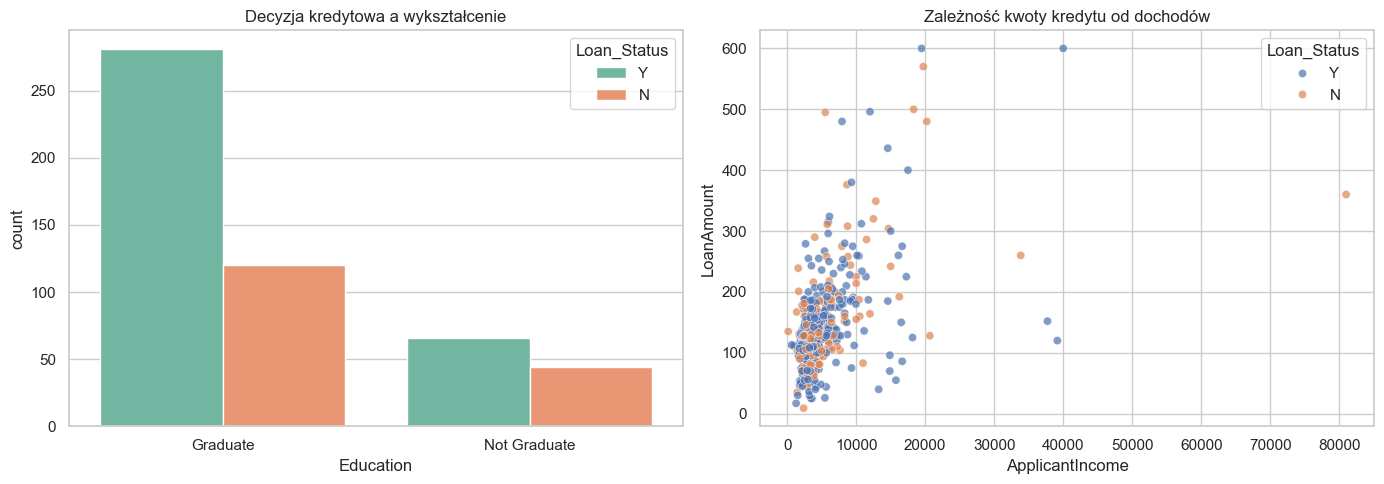

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(ax=axes[0], data=df, x='Education', hue='Loan_Status', palette='Set2')
axes[0].set_title('Decyzja kredytowa a wykształcenie')

sns.scatterplot(ax=axes[1], data=df, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', alpha=0.7)
axes[1].set_title('Zależność kwoty kredytu od dochodów')

plt.tight_layout()
plt.show()

Interpretacja wykresów
powyższe wykresy dostarczają nam kluczowych informacji na temat czynników wpływających na decyzje kredytowe:
1.  decyzja kredytowa a wykształcenie:
wyraźnie pokazuje, że w badanym zbiorze danych dominuje grupa z wykształceniem wyższym (Graduate). To w tej grupie odnotowujemy znacznie więcej pozytywnych decyzji kredytowych. Jednocześnie, wskaźnik odmów w grupie bez wyższego wykształcenia (Not Graduate) jest proporcjonalnie wyższy w stosunku do liczby przyznanych kredytów w tej kategorii, co sugeruje silną korelację między wykształceniem a szansą na otrzymanie finansowania.
2.  kwota kredytu a dochód:
Potwierdza logiczną i silną zależność: im wyższe dochody wnioskodawcy, tym wyższa wnioskowana kwota kredytu. Na wykresie widać wyraźny trend rosnący. Rozkład punktów sugeruje również, że większość wnioskodawców grupuje się w niższych przedziałach dochodów, ale to właśnie tam dochodzi do największej liczby decyzji kredytowych (zarówno pozytywnych, jak i negatywnych). Ponadto, widać, że osoby o bardzo wysokich dochodach aplikują o proporcjonalnie znacznie wyższe kwoty kredytów, co jest naturalnym zjawiskiem.
podsumowanie: Zarówno wykształcenie, jak i dochody są istotnymi predyktorami, które bank bierze pod uwagę. Osoby z wykształceniem wyższym oraz te o wyższych dochodach mają statystycznie większe szanse na pozytywne rozpatrzenie wniosku o kredyt hipoteczny.

Wnioski
- najwięcej wniosków o kredyt składają osoby z wyższym wykształceniem.
- wykształcenie pozytywnie koreluje z przyznawalnością kredytu.
- Zauważalna jest wyraźna zależność - osoby o wyższych dochodach aplikują o wyższe kwoty kredytów hipotecznych